In [2]:
#import atlite

import logging
logging.basicConfig(level=logging.INFO)

import geopandas as gpd

import matplotlib.pyplot as plt

#from atlite.gis import shape_availability, ExclusionContainer

import xarray as xr

import numpy as np
import pandas as pd

import requests

import io

import os

from shapely.geometry import Polygon
from shapely.geometry import Point

import cartopy.io.shapereader as shpreader
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.crs import CRS

from affine import Affine

import shapely
from shapely.geometry import Polygon
from shapely.geometry import mapping
from shapely.geometry import box
#from pyhighRES import constants

In [2]:
shapefile = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')
world = gpd.read_file(shapefile)
Norway = world[world.iso_a2=="NO"]
Norway = Norway[["iso_3166_2","name","geometry"]]
Norway = Norway.set_index('iso_3166_2').drop(['NO-21', 'NO-X01~'])

In [3]:
Norway

,name,geometry
iso_3166_2,,
NO-19,Troms,"MULTIPOLYGON (((20.62316 69.03636, 20.36272 69..."
NO-18,Nordland,"MULTIPOLYGON (((18.18929 68.53842, 18.17184 68..."
NO-17,Nord-Trøndelag,"MULTIPOLYGON (((14.33207 65.11396, 14.31068 65..."
NO-16,Sør-Trøndelag,"MULTIPOLYGON (((12.05983 63.20477, 12.22270 63..."
NO-04,Hedmark,"POLYGON ((12.27952 62.34421, 12.28636 62.33542..."
NO-02,Akershus,"POLYGON ((11.87463 59.88494, 11.84959 59.87242..."
NO-01,Østfold,"MULTIPOLYGON (((11.88374 59.80538, 11.88980 59..."
NO-20,Finnmark,"MULTIPOLYGON (((28.95408 69.02726, 28.83961 69..."
NO-03,Oslo,"POLYGON ((10.75660 59.84416, 10.75847 59.85017..."


In [4]:
Trøndelag = gpd.GeoDataFrame([{'name':'Trøndelag', 'geometry':Norway.loc[['NO-17', 'NO-16']].unary_union}], index=['NO-50'])
TromsFinnmark = gpd.GeoDataFrame([{'name':'Troms og Finnmark', 'geometry':Norway.loc[['NO-19', 'NO-20']].unary_union}], index=['NO-54'])
Vestland = gpd.GeoDataFrame([{'name':'Vestland', 'geometry':Norway.loc[['NO-12', 'NO-14']].unary_union}], index=['NO-46'])
Viken = gpd.GeoDataFrame([{'name':'Viken', 'geometry':Norway.loc[['NO-02', 'NO-06', 'NO-01']].unary_union}], index=['NO-30'])
Innlandet = gpd.GeoDataFrame([{'name':'Innlandet', 'geometry':Norway.loc[['NO-04', 'NO-05']].unary_union}], index=['NO-34'])
VestfoldTelemark = gpd.GeoDataFrame([{'name':'Vestfold og Telemark', 'geometry':Norway.loc[['NO-07', 'NO-08']].unary_union}], index=['NO-38'])
Agder = gpd.GeoDataFrame([{'name':'Agder', 'geometry':Norway.loc[['NO-09', 'NO-10']].unary_union}], index=['NO-42'])
Nordland = gpd.GeoDataFrame([{'name':'Nordland', 'geometry':Norway.loc[['NO-18']].explode().drop(('NO-18',25)).unary_union}], index=['NO-18'])

Norway_11 = Norway.drop(['NO-17', 'NO-16', 'NO-19', 'NO-20', 'NO-12', 'NO-14', 'NO-02', 'NO-06',
                          'NO-01', 'NO-04', 'NO-05', 'NO-07', 'NO-08', 'NO-09', 'NO-10', 'NO-18'])

/tmp/ipykernel_31651/2684897047.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  Nordland = gpd.GeoDataFrame([{'name':'Nordland', 'geometry':Norway.loc[['NO-18']].explode().drop(('NO-18',25)).unary_union}], index=['NO-18'])


In [5]:
Norway_11 = pd.concat([Norway_11, Trøndelag.set_crs(Norway_11.crs), TromsFinnmark.set_crs(Norway_11.crs),
                    Vestland.set_crs(Norway_11.crs), Viken.set_crs(Norway_11.crs), Innlandet.set_crs(Norway_11.crs),
                    VestfoldTelemark.set_crs(Norway_11.crs), Agder.set_crs(Norway_11.crs), Nordland.set_crs(Norway_11.crs)])

<AxesSubplot: >

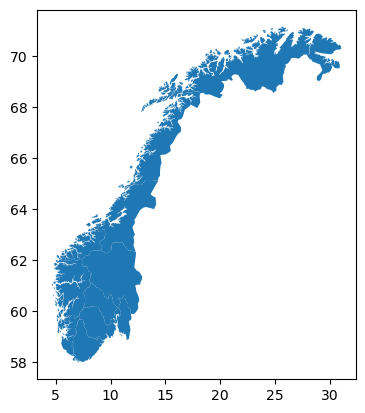

In [6]:
Norway_11 = Norway_11.sort_index()
Norway_11.plot()

In [7]:
Norway_11.index.name = 'fylke_code'

In [8]:
Norway_11.query("fylke_code == 'NO-03'")

,name,geometry
fylke_code,,
NO-03,Oslo,"POLYGON ((10.75660 59.84416, 10.75847 59.85017..."


In [20]:
pd.set_option('display.max_colwidth', None)
Norway_11

name  \
fylke_code                         
NO-03                       Oslo   
NO-11                   Rogaland   
NO-15            Møre og Romsdal   
NO-18                   Nordland   
NO-30                      Viken   
NO-34                  Innlandet   
NO-38       Vestfold og Telemark   
NO-42                      Agder   
NO-46                   Vestland   
NO-50                  Trøndelag   
NO-54          Troms og Finnmark   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [22]:
NIBIO = pd.read_csv("/fp/homes01/u01/ec-javedm/ec85/models/shahzad/highRES-model/NIBIO_data.csv")

In [24]:
NIBIO['REGION'].unique()

array(['Sørlandet', 'Vestlandet', 'Østlandet', 'Trøndelag', 'Nord-Norge'],
      dtype=object)

In [25]:
NIBIO

,FLATEID,SESONG,LOREYS_HEIGHT,UTM_S33_OV_CA,UTM_S33_SN_CA,ABONITET,BEST_ALDER,SKOGKARAKTER,FAWS,FYLKESNAVN,REGION
0,A03059,2019,17.94,16000.0,6466000.0,11.0,65.0,1,0,Agder,Sørlandet
1,A03099,2023,4.40,9000.0,6476000.0,NaN,55.0,1,0,Agder,Sørlandet
2,A03102,2020,6.80,14000.0,6469000.0,11.0,NaN,1,1,Agder,Sørlandet
3,A03105,2020,8.51,14000.0,6472000.0,NaN,27.0,1,0,Agder,Sørlandet
4,A03107,2020,6.83,12000.0,6475000.0,NaN,65.0,1,0,Agder,Sørlandet
...,...,...,...,...,...,...,...,...,...,...,...
10505,A08172,2020,0.00,40000.0,6529000.0,NaN,85.0,1,0,Agder,Sørlandet
10506,A44071,2022,0.00,90000.0,6914000.0,NaN,55.0,1,0,Møre og Romsdal,Vestlandet
10507,A35012,2022,0.00,25000.0,6822000.0,NaN,53.0,1,0,Vestland,Vestlandet
10508,D72042,2020,0.00,498000.0,7401000.0,NaN,90.0,1,0,Nordland,Nord-Norge


In [29]:
NIBIO['geometry'] = NIBIO.apply(lambda row: Point(row['UTM_S33_OV_CA'], row['UTM_S33_SN_CA']), axis=1)

In [31]:
NIBIO_gdf = gpd.GeoDataFrame(NIBIO, geometry='geometry', crs="EPSG:32633")

In [33]:
NIBIO_gdf = NIBIO_gdf.to_crs(epsg=4326)

In [34]:
NIBIO_gdf

,FLATEID,SESONG,LOREYS_HEIGHT,UTM_S33_OV_CA,UTM_S33_SN_CA,ABONITET,BEST_ALDER,SKOGKARAKTER,FAWS,FYLKESNAVN,REGION,geometry
0,A03059,2019,17.94,16000.0,6466000.0,11.0,65.0,1,0,Agder,Sørlandet,POINT (6.78335 58.06968)
1,A03099,2023,4.40,9000.0,6476000.0,NaN,55.0,1,0,Agder,Sørlandet,POINT (6.64504 58.15086)
2,A03102,2020,6.80,14000.0,6469000.0,11.0,NaN,1,1,Agder,Sørlandet,POINT (6.74360 58.09416)
3,A03105,2020,8.51,14000.0,6472000.0,NaN,27.0,1,0,Agder,Sørlandet,POINT (6.73739 58.12082)
4,A03107,2020,6.83,12000.0,6475000.0,NaN,65.0,1,0,Agder,Sørlandet,POINT (6.69755 58.14529)
...,...,...,...,...,...,...,...,...,...,...,...,...
10505,A08172,2020,0.00,40000.0,6529000.0,NaN,85.0,1,0,Agder,Sørlandet,POINT (7.06065 58.65568)
10506,A44071,2022,0.00,90000.0,6914000.0,NaN,55.0,1,0,Møre og Romsdal,Vestlandet,POINT (7.12379 62.13331)
10507,A35012,2022,0.00,25000.0,6822000.0,NaN,53.0,1,0,Vestland,Vestlandet,POINT (6.13132 61.24142)
10508,D72042,2020,0.00,498000.0,7401000.0,NaN,90.0,1,0,Nordland,Nord-Norge,POINT (14.95464 66.72747)


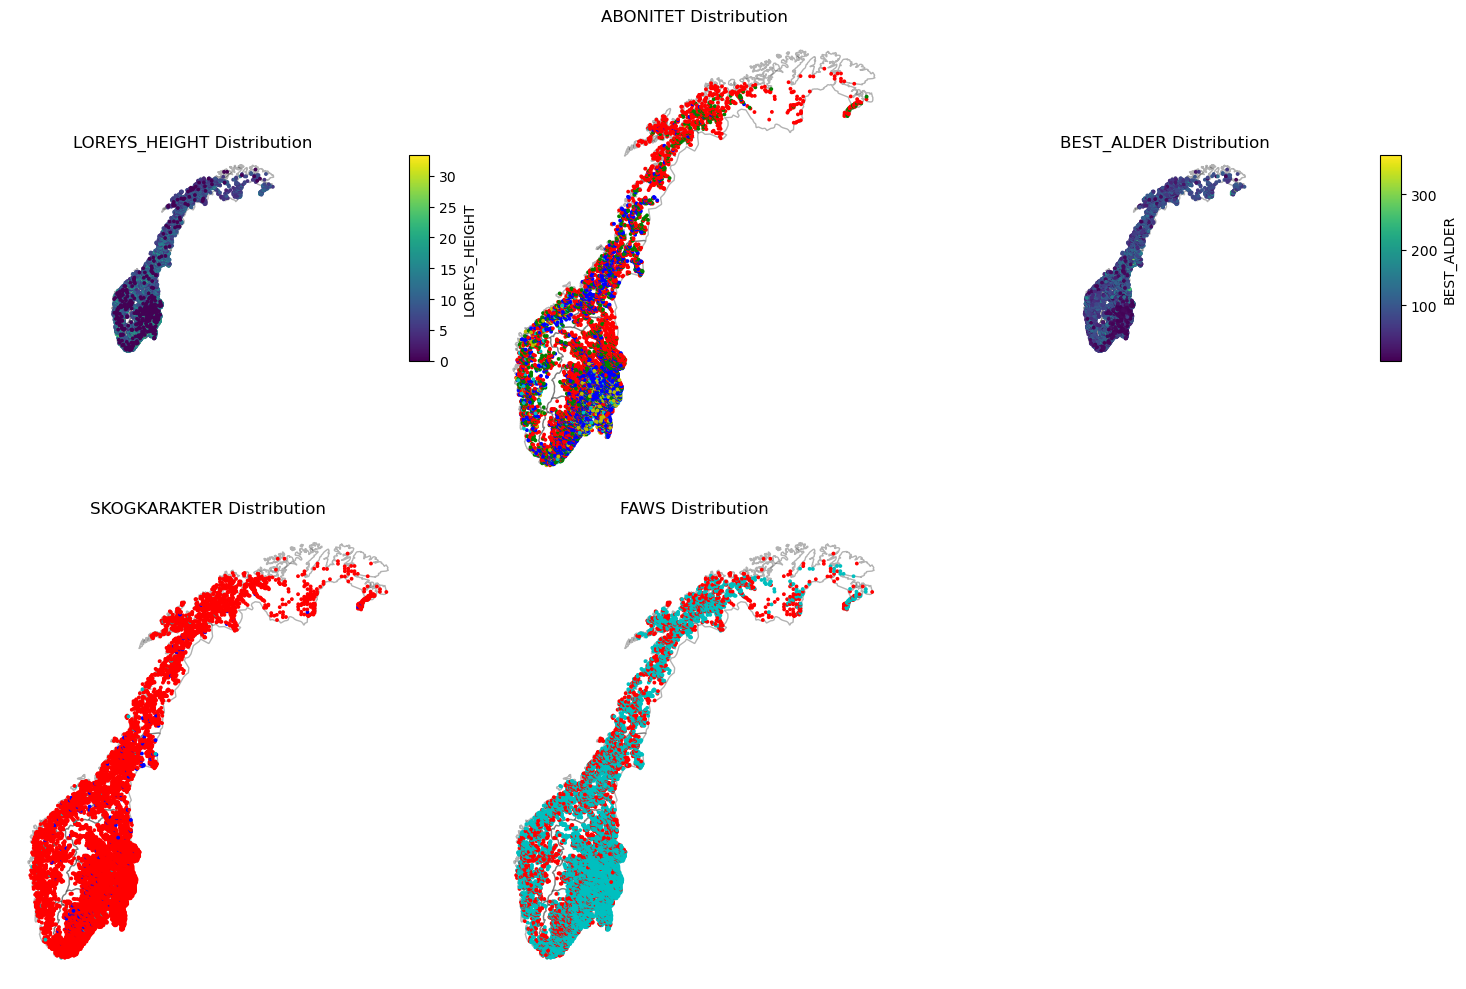

In [48]:
# Plot settings
categories = ['LOREYS_HEIGHT', 'ABONITET', 'BEST_ALDER', 'SKOGKARAKTER', 'FAWS']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

ax = axes[idx]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
dropna = NIBIO_gdf.dropna(subset=['ABONITET'])
cmap = ListedColormap(['r', 'g', 'b', 'y', 'c'])
dropna.plot(ax=ax,
            column=category,
            cmap=cmap, 
            markersize=3)
ax.set_title(f'{category} Distribution', fontsize=12)
ax.set_axis_off()


for idx, category in enumerate(categories):
    ax = axes[idx]
    Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
    dropna = NIBIO_gdf.dropna(subset=[category])
    if category in ['LOREYS_HEIGHT', 'BEST_ALDER']:  # Continuous
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        
        
        dropna.plot(ax=ax,
                 column=category, 
                 cmap='viridis',
                 markersize=3,
                 legend=True,
                 cax=cax,
                 legend_kwds={'label': category, 'orientation': "vertical"})
    else:  # Discrete values
        cmap = ListedColormap(['r', 'g', 'b', 'y', 'c'])
        dropna.plot(ax=ax,
                 column=category,
                 cmap=cmap, 
                 markersize=3)

    # Highlight NaN values with different markers
    #nan_gdf = NIBIO_gdf[NIBIO_gdf[category].isnull()]
    #nan_gdf.plot(ax=ax, color='grey', markersize=50, marker='x', label="Missing Data")

    # Custom plot settings
    ax.set_title(f'{category} Distribution', fontsize=12)
    ax.set_axis_off()

# Hide any unused subplots
for ax in axes[len(categories):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [112]:
print(NIBIO_gdf['FAWS'].value_counts(normalize=True).sort_index())

0    0.266698
1    0.733302
Name: FAWS, dtype: float64


In [69]:
NIBIO_gdf[NIBIO_gdf['ABONITET'].isnull()]

,FLATEID,SESONG,LOREYS_HEIGHT,UTM_S33_OV_CA,UTM_S33_SN_CA,ABONITET,BEST_ALDER,SKOGKARAKTER,FAWS,FYLKESNAVN,REGION,geometry
1,A03099,2023,4.40,9000.0,6476000.0,NaN,55.0,1,0,Agder,Sørlandet,POINT (6.64504 58.15086)
3,A03105,2020,8.51,14000.0,6472000.0,NaN,27.0,1,0,Agder,Sørlandet,POINT (6.73739 58.12082)
4,A03107,2020,6.83,12000.0,6475000.0,NaN,65.0,1,0,Agder,Sørlandet,POINT (6.69755 58.14529)
6,A03143,2022,9.16,9000.0,6479000.0,NaN,62.0,1,0,Agder,Sørlandet,POINT (6.63874 58.17752)
9,A03156,2023,18.81,18000.0,6480000.0,NaN,55.0,1,0,Agder,Sørlandet,POINT (6.78812 58.19631)
...,...,...,...,...,...,...,...,...,...,...,...,...
10505,A08172,2020,0.00,40000.0,6529000.0,NaN,85.0,1,0,Agder,Sørlandet,POINT (7.06065 58.65568)
10506,A44071,2022,0.00,90000.0,6914000.0,NaN,55.0,1,0,Møre og Romsdal,Vestlandet,POINT (7.12379 62.13331)
10507,A35012,2022,0.00,25000.0,6822000.0,NaN,53.0,1,0,Vestland,Vestlandet,POINT (6.13132 61.24142)
10508,D72042,2020,0.00,498000.0,7401000.0,NaN,90.0,1,0,Nordland,Nord-Norge,POINT (14.95464 66.72747)


/tmp/ipykernel_310014/3437490900.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


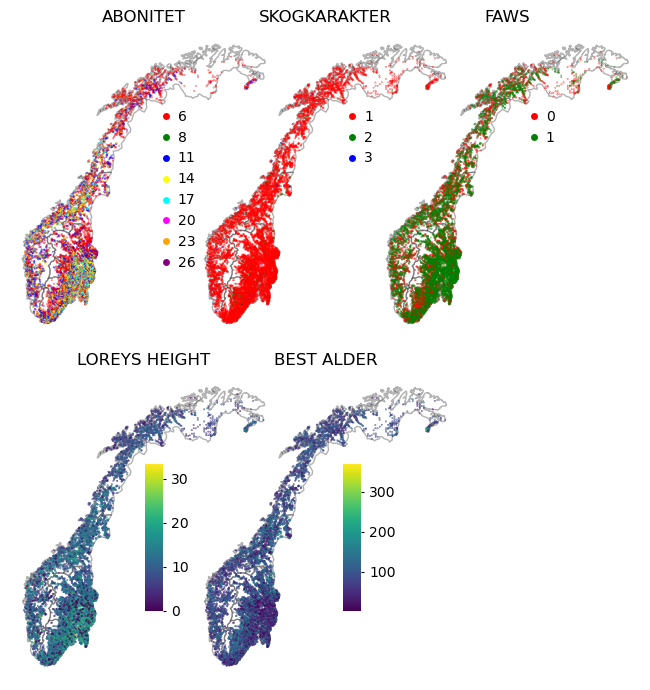

In [111]:
categories = ['LOREYS_HEIGHT', 'ABONITET', 'BEST_ALDER', 'SKOGKARAKTER', 'FAWS']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9, 7))
fig.subplots_adjust(wspace=-1.2, left=0.15, right=0.75, top=1, bottom=0.2)
axes = axes.flatten()

abonitet_cmap = ListedColormap(['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'grey'])
skogkarakter_cmap = ListedColormap(['red', 'green', 'blue'])
faws_cmap = ListedColormap(['red', 'green'])


ax = axes[0]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
gdf_abonitet = NIBIO_gdf.dropna(subset=['ABONITET'])
#nan_gdf_abonitet = NIBIO_gdf[NIBIO_gdf['ABONITET'].isnull()]
#nan_gdf_abonitet.plot(ax=ax, color='grey', marker='x', markersize=0.1, label='Missing Data')
gdf_abonitet.plot(ax=ax,
            column='ABONITET',
            cmap=abonitet_cmap, 
            markersize=0.05)

legend_labels = ['6', '8', '11', '14', '17', '20', '23', '26']
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'grey']
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=6, label=label)
                   for color, label in zip(colors, legend_labels)]

ax.legend(handles=legend_elements, title="", loc='upper center', bbox_to_anchor=(0.63, 0.76), borderaxespad=0, frameon=False, 
          fontsize=10, handlelength=0.7, handletextpad=0.5)

ax.set_title( 'ABONITET', fontsize=12)
ax.set_axis_off()


ax = axes[1]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
#dropna = NIBIO_gdf.dropna(subset=['SKOGKARAKTER'])
NIBIO_gdf.plot(ax=ax,
            column='SKOGKARAKTER',
            cmap=skogkarakter_cmap, 
            markersize=0.05)

legend_labels = ['1', '2', '3']
colors = ['red', 'green', 'blue']
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=6, label=label)
                   for color, label in zip(colors, legend_labels)]
ax.legend(handles=legend_elements, title="", loc='upper center', bbox_to_anchor=(0.63, 0.76), borderaxespad=0, frameon=False, 
          fontsize=10, handlelength=0.7, handletextpad=0.5)

ax.set_title( 'SKOGKARAKTER', fontsize=12)
ax.set_axis_off()


ax = axes[2]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
#dropna = NIBIO_gdf.dropna(subset=['SKOGKARAKTER'])
NIBIO_gdf.plot(ax=ax,
            column='FAWS',
            cmap=faws_cmap, 
            markersize=0.05)


legend_labels = ['0', '1']
colors = ['red', 'green']
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=6, label=label)
                   for color, label in zip(colors, legend_labels)]
ax.legend(handles=legend_elements, title="", loc='upper center', bbox_to_anchor=(0.63, 0.76), borderaxespad=0, frameon=False, 
          fontsize=10, handlelength=0.7, handletextpad=0.5)


ax.set_title( 'FAWS', fontsize=12)
ax.set_axis_off()

ax = axes[3]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
#dropna = NIBIO_gdf.dropna(subset=['SKOGKARAKTER'])
#divider = make_axes_locatable(ax)
#cax = divider.append_axes("right", size="3%", pad=-1)
NIBIO_gdf.plot(ax=ax,
            column='LOREYS_HEIGHT', 
            cmap='viridis',
            markersize=0.1,
            legend=False,
              )

ax_color_scale = fig.add_axes([0.3, 0.12, 0.02, 0.21])
norm = plt.Normalize(vmin=NIBIO_gdf['LOREYS_HEIGHT'].min(), 
                         vmax=NIBIO_gdf['LOREYS_HEIGHT'].max())
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), 
                      cax=ax_color_scale, orientation='vertical')
cb.set_label('', fontsize=10)
#new_ticks = [0, 100, 200, 300]
#cb.set_ticks(new_ticks)
cb.outline.set_visible(False)
cb.ax.tick_params(length=2)

ax.set_title( 'LOREYS HEIGHT', fontsize=12)
ax.set_axis_off()


ax = axes[4]
Norway_11.plot(ax=ax, facecolor="none", edgecolor="black", alpha=0.3)
gdf_best_alder = NIBIO_gdf.dropna(subset=['BEST_ALDER'])
gdf_best_alder.plot(ax=ax,
            column='BEST_ALDER', 
            cmap='viridis',
            markersize=0.1,
            legend=False,
                   )

ax_color_scale = fig.add_axes([0.52, 0.12, 0.02, 0.21])
norm = plt.Normalize(vmin=NIBIO_gdf['BEST_ALDER'].min(), 
                         vmax=NIBIO_gdf['BEST_ALDER'].max())
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), 
                      cax=ax_color_scale, orientation='vertical')
cb.set_label('', fontsize=10)
cb.outline.set_visible(False)
cb.ax.tick_params(length=2)
ax.set_title( 'BEST ALDER', fontsize=12)
ax.set_axis_off()


axes[-1].set_visible(False)
plt.tight_layout()

plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/Forests_plot.png', dpi=300, bbox_inches='tight')
#plt.savefig('/fp/homes01/u01/ec-javedm/ec85/models/shahzad/Plots/updated/transperent/store_ecap_zonal2.png', dpi=300, transparent=True, bbox_inches='tight')


plt.show()

In [15]:
# Function for obtaining bounding box in the new CRS

def get_bounding():
    rectx1 = 4.5936268
    rectx2 = 33.2415665
    recty1 = 57.408891
    recty2 = 71.339783
    
    polygon = Polygon(
        [
            (rectx1, recty1),
            (rectx1, recty2),
            (rectx2, recty2),
            (rectx2, recty1),
            (rectx1, recty1),
        ]
    )
    
    # Segmentize or refine polygon
    polygon = shapely.segmentize(polygon, max_segment_length=0.5)
    geo_df = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326")
    # Re-project to new CRS
    return geo_df.to_crs("EPSG:3035")

## Bonitet (SRBONITET)

In [279]:

def process_rasterize_SRRBONITET_one(tiff_in, band_index, categories_to_include, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        processed_data = np.where(data == -9999, 255,
                          np.where(np.isin(data, categories_to_include), 1, 0)).astype(np.uint8)

        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    



In [280]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_SRRBONITET_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [192]:
def process_rasterize_SRRBONITET(tiff_in, categories_to_include, out_shape):
    
    with rasterio.open(tiff_in) as src:
    # Read the data
        data = src.read(1)  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds
        
        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)
    
        # Retrieve metadata if needed
        kwargs = src.meta.copy()
    
        kwargs.update({
        'crs': CRS.from_epsg(3035),
        'transform': new_transform,
        'width': new_width,
        'height': new_height,
        'dtype': 'uint8',
        'nodata': 0,  # Setting nodata to zero for binary   
        #'compress': 'lzw',  # Add LZW compression
        'compress': 'deflate'  # Add LZW compression    
        })
    
        # Create an empty array for the destination data
        #dst_array = np.zeros((new_height, new_width), dtype=np.uint8)
        dst_array = np.full((new_height, new_width), -9999, dtype=np.int32)
        
        reproject(
            source=rasterio.band(src, 1),  # Use processed binary exclusion data
            destination=dst_array,  # Initialize destination array
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=new_transform,
            dst_crs=CRS.from_epsg(3035),
            resampling=Resampling.nearest
        )
    
        # Convert reprojected data to binary mask
        binary_data = np.isin(dst_array, categories_to_include).astype(np.uint8)
    
        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
             dst.write(binary_data, 1)    
            


In [281]:
#total categories: [-9999,     0,     6,     8,    11,    14,    17,    20,    23] with -9999 nodata
categories_to_include_low = [0, 6, 8, 11, 14]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PLi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_low, out_shape)

In [282]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBONITET_PLF.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

In [283]:
categories_to_include_high = [0, 6, 8]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PHi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_to_include_high, out_shape)

In [284]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBONITET_PHF.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

In [285]:
#Remaining categories to cross check
categories_not__notincluded = [17, 20, 23]
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBONITET.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PHLi.tif'
process_rasterize_SRRBONITET_one(tiff_in_BONITET, 1, categories_not__notincluded, out_shape)


In [286]:
tiff_in_BONITET = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBONITET_PHLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBONITET_PHLF.tif'
process_rasterize_SRRBONITET_two(tiff_in_BONITET, out_shape)

## Biomasse overjordisk (SRBMO)

In [251]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_biomass(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        # Create an empty array for the destination data
        dst_array = np.zero((new_height, new_width), -9999, dtype=np.int16)  # Init with nodata
        
        # Reproject the data
        reproject(
            source=data,
            destination=dst_array,
            destination=out_shape,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=new_transform,
            dst_crs=CRS.from_epsg(3035),
            resampling=Resampling.nearest
        )

        print(np.unique(dst_array))
        # Convert reprojected data to binary mask based on the threshold
        binary_data = ((dst_array >= 0) & (dst_array < threshold)).astype(np.uint8)

        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            dst.write(binary_data, 1)    



In [287]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_biomass_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, -127,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [288]:
#Biomass data: range is [0 to 826] in tonn/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_biomass_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [289]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PLi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  200, out_shape)

In [290]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PLF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [291]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PMi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  150, out_shape)

In [292]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PMF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [293]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PHi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  100, out_shape)

In [294]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PHF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [295]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PHHi.tif'
process_rasterize_biomass_one(tiff_in_BMO, 1,  50, out_shape)

In [296]:
tiff_in_BMO = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRBMO_PHHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRBMO_PHHF.tif'
process_rasterize_biomass_two(tiff_in_BMO, out_shape)

In [249]:
np.unique(binary_data)

array([0, 1], dtype=uint8)

## Treantall

In [319]:
#Treantall data with diameter greater then 5 cm: range is [0 to 5384] in tree/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_treantall_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, -127,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [320]:

#TODO: description of band_index...
def process_rasterize_treantall_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [321]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PLi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  1200, out_shape)


In [322]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREANTALL_PLF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

In [323]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PMi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  800, out_shape)


In [324]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREANTALL_PMF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

In [325]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PHi.tif'
process_rasterize_treantall_one(tiff_in_treantall, 1,  400, out_shape)

In [326]:
tiff_in_treantall = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREANTALL_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREANTALL_PHF.tif'
process_rasterize_treantall_two(tiff_in_treantall, out_shape)

## Tree age (TREALDER)

In [9]:
#Trealder data with for tree ages range is [0 to 365] in years. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_trealder_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, -127,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [10]:

#TODO: description of band_index...
def process_rasterize_trealder_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [12]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PLi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  120, out_shape)


In [16]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREALDER_PLF.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

In [17]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PMi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  100, out_shape)


In [18]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREALDER_PMF.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

In [19]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PHi.tif'
process_rasterize_trealder_one(tiff_in_trealder, 1,  80, out_shape)


In [20]:
tiff_in_trealder = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRTREALDER_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRTREALDER_PHF.tif'
process_rasterize_trealder_two(tiff_in_trealder, out_shape)

## Basal area (Grunnflate)

In [21]:
#Basal area data for how dense trees are, range is [0 to 125] in m2/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_grunnflate_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, 255,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.uint8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [22]:

#TODO: description of band_index...
def process_rasterize_grunnflate_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [23]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PLi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, 25, out_shape)


In [24]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRGRFLATE_PLF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

In [25]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PMi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, 15, out_shape)


In [26]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRGRFLATE_PMF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

In [27]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PHi.tif'
process_rasterize_grunnflate_one(tiff_in_grunfalte, 1, 5, out_shape)


In [28]:
tiff_in_grunfalte = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRGRFLATE_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRGRFLATE_PHF.tif'
process_rasterize_grunnflate_two(tiff_in_grunfalte, out_shape)

## Volume with bark (SRVOLMB)

In [29]:
#Volume with bark data with for the volume of tress timber range is [0 to 1250] in m3/ha. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_volmb_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'int8',
            'nodata': -127,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, -127,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.int8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [30]:

#TODO: description of band_index...
def process_rasterize_volmb_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [31]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PLi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, 150, out_shape)


In [32]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRVOLMB_PLF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

In [33]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PMi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, 100, out_shape)


In [34]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRVOLMB_PMF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

In [35]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PHi.tif'
process_rasterize_volmb_one(tiff_in_volmb, 1, 50, out_shape)


In [36]:
tiff_in_volmb = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRVOLMB_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRVOLMB_PHF.tif'
process_rasterize_volmb_two(tiff_in_volmb, out_shape)

## Ground area covered with crown (SRKRONEDEK)

In [37]:
#Percent of ground area covered with tree crowns data for how dense trees are, range is [0 to 100] in percent. -9999 represents nodata
#TODO: description of band_index...
def process_rasterize_KRONEDEK_one(tiff_in, band_index, threshold, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read(band_index)  # Reads the first band of the image

        # Retrieve metadata if needed
        kwargs = src.meta.copy()
        
        kwargs.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255,  # Set nodata to zero for binary representation
            'compress': 'deflate'  # Add compression
        })

        #binary_data = np.where((data >= 0) & (data < threshold), 1, 0).astype(np.uint8)
        processed_data = np.where(data == -9999, 255,
                                  np.where((data >= 0) & (data < threshold), 1, 0)).astype(np.uint8)
        with rasterio.open(out_shape, 'w', **kwargs) as dst:          
            dst.write(processed_data, 1)    


In [38]:

#TODO: description of band_index...
def process_rasterize_KRONEDEK_two(tiff_in, out_shape):
    with rasterio.open(tiff_in) as src:
        # Read the data
        data = src.read()  # Reads the first band of the image
        minx, miny, maxx, maxy = get_bounding().total_bounds

        # Calculate new transform
        new_transform = Affine.translation(minx, maxy) * Affine.scale(
            (maxx - minx) / src.width,
            (miny - maxy) / src.height
        )
        
        # Calculate new width and height
        new_width = int((maxx - minx) / new_transform.a)
        new_height = int((maxy - miny) / -new_transform.e)

        # Retrieve metadata if needed
        kwargs = src.meta.copy()

        kwargs.update({
            'crs': CRS.from_epsg(3035),
            'transform': new_transform,
            'width': new_width,
            'height': new_height,
            'compress': 'deflate'  # Add compression
        })


        with rasterio.open(out_shape, 'w', **kwargs) as dst:  
            # Reproject the data
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=CRS.from_epsg(3035),
                resampling=Resampling.nearest
            )    


In [39]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PLi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, 85, out_shape)


In [40]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PLi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRKRONEDEK_PLF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

In [41]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PMi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, 70, out_shape)


In [42]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PMi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRKRONEDEK_PMF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

In [43]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PHi.tif'
process_rasterize_KRONEDEK_one(tiff_in_krone, 1, 50, out_shape)


In [44]:
tiff_in_krone = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/intermediate_processed/SRRKRONEDEK_PHi.tif'
out_shape = '/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/Processed/SRRKRONEDEK_PHF.tif'
process_rasterize_KRONEDEK_two(tiff_in_krone, out_shape)

In [153]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRMHOYDE.tif') as src_mohoy:
    # Read the data
        data_mhoy = src_mohoy.read(1)  # Reads the first band of the image


In [154]:
np.unique(data_mhoy)

array([-9999,     0,     1,     2,     3,     4,     5,     6,     7,
           8,     9,    10,    11,    12,    13,    14,    15,    16,
          17,    18,    19,    20,    21,    22,    23,    24,    25,
          26,    27,    28,    29,    30,    31,    32,    33,    34,
          35,    36,    37,    38,    39,    40,    41,    42,    43,
          44,    45,    46,    47,    48,    49,    50,    51,    52,
          53,    54,    55,    56,    57,    58,    59,    60,    61,
          62,    63,    64,    65,    66,    67,    68,    69,    70,
          71,    72,    73,    74,    75,    76,    77,    78,    79,
          80,    81,    82,    83,    84,    85,    86,    87,    88,
          89,    90,    91,    92,    93,    94,    95,    96,    97,
          98,    99,   100,   101,   102,   103,   104,   105,   106,
         107,   108,   109,   110,   111,   112,   113,   114,   115,
         116,   117,   118,   119,   120,   121,   122,   123,   124,
         125,   126,

In [203]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif') as src_BMO:
    # Read the data
        data_BMO = src_BMO.read(1)  # Reads the first band of the image
        data_BMO2 = src_BMO.read(2)
        data_BMO3 = src_BMO.read(3)

In [212]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMU.tif') as src_BMU:
    # Read the data
        data_BMU = src_BMU.read(1)  # Reads the first band of the image
        data_BMU2 = src_BMU.read(2)
        data_BMU3 = src_BMU.read(3)

In [307]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif') as src_TREA:
    # Read the data
        data_TREA1 = src_TREA.read(1)  # Reads the first band of the image
        data_TREA2 = src_TREA.read(2)
        data_TREA3 = src_TREA.read(3)

In [298]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL_GE8.tif') as src_TREA8:
    # Read the data
        data_TREA8 = src_TREA8.read(1)  # Reads the first band of the image
        #data_BMO2 = src_BMO.read(2)
        #data_BMO3 = src_BMO.read(3)

In [299]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL_GE10.tif') as src_TREA10:
    # Read the data
        data_TREA10 = src_TREA10.read(1)  # Reads the first band of the image
        #data_BMO2 = src_BMO.read(2)
        #data_BMO3 = src_BMO.read(3)

In [300]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL_GE16.tif') as src_TREA16:
    # Read the data
        data_TREA16 = src_TREA16.read(1)  # Reads the first band of the image
        #data_BMO2 = src_BMO.read(2)
        #data_BMO3 = src_BMO.read(3)

In [338]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif') as src_TREALD:
    # Read the data
        data_TREALD1 = src_TREALD.read(1)  # Reads the first band of the image
        data_TREALD2 = src_TREALD.read(2)
        data_TREALD3 = src_TREALD.read(3)

In [327]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif') as src_GRF:
    # Read the data
        data_GRF1 = src_GRF.read(1)  # Reads the first band of the image
        data_GRF2 = src_GRF.read(2)
        data_GRF3 = src_GRF.read(3)

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif') as src_KRO:
    # Read the data
        data_KRO1 = src_KRO.read(1)  # Reads the first band of the image

In [335]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif') as src_VOLMB:
    # Read the data
        data_VOLMB1 = src_VOLMB.read(1)  # Reads the first band of the image
        data_VOLMB2 = src_VOLMB.read(2)
        data_VOLMB3 = src_VOLMB.read(3)

In [336]:
src_VOLMB.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -9999.0,
 'width': 78325,
 'height': 96822,
 'count': 3,
 'crs': CRS.from_epsg(25833),
 'transform': Affine(16.0, 0.0, -95616.0,
        0.0, -16.0, 7985152.0)}

In [337]:
src_TREALD.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -9999.0,
 'width': 78325,
 'height': 96822,
 'count': 3,
 'crs': CRS.from_epsg(25833),
 'transform': Affine(16.0, 0.0, -95616.0,
        0.0, -16.0, 7985152.0)}

In [333]:
src_KRO.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -9999.0,
 'width': 78325,
 'height': 96822,
 'count': 1,
 'crs': CRS.from_epsg(25833),
 'transform': Affine(16.0, 0.0, -95616.0,
        0.0, -16.0, 7985152.0)}

In [339]:
np.unique(data_TREALD1)

array([-9999,     0,     1,     2,     3,     4,     5,     6,     7,
           8,     9,    10,    11,    12,    13,    14,    15,    16,
          17,    18,    19,    20,    21,    22,    23,    24,    25,
          26,    27,    28,    29,    30,    31,    32,    33,    34,
          35,    36,    37,    38,    39,    40,    41,    42,    43,
          44,    45,    46,    47,    48,    49,    50,    51,    52,
          53,    54,    55,    56,    57,    58,    59,    60,    61,
          62,    63,    64,    65,    66,    67,    68,    69,    70,
          71,    72,    73,    74,    75,    76,    77,    78,    79,
          80,    81,    82,    83,    84,    85,    86,    87,    88,
          89,    90,    91,    92,    93,    94,    95,    96,    97,
          98,    99,   100,   101,   102,   103,   104,   105,   106,
         107,   108,   109,   110,   111,   112,   113,   114,   115,
         116,   117,   118,   119,   120,   121,   122,   123,   124,
         125,   126,

In [340]:
np.unique(data_TREALD2)

array([-9999,     0,     1, ..., 31536, 31670, 31931], dtype=int16)

In [341]:
np.unique(data_TREALD3)

array([-9999,     0,     4, ..., 31540, 31676, 31936], dtype=int16)

In [334]:
np.unique(data_KRO1)

array([-9.999e+03,  0.000e+00,  1.000e+00,  2.000e+00,  3.000e+00,
        4.000e+00,  5.000e+00,  6.000e+00,  7.000e+00,  8.000e+00,
        9.000e+00,  1.000e+01,  1.100e+01,  1.200e+01,  1.300e+01,
        1.400e+01,  1.500e+01,  1.600e+01,  1.700e+01,  1.800e+01,
        1.900e+01,  2.000e+01,  2.100e+01,  2.200e+01,  2.300e+01,
        2.400e+01,  2.500e+01,  2.600e+01,  2.700e+01,  2.800e+01,
        2.900e+01,  3.000e+01,  3.100e+01,  3.200e+01,  3.300e+01,
        3.400e+01,  3.500e+01,  3.600e+01,  3.700e+01,  3.800e+01,
        3.900e+01,  4.000e+01,  4.100e+01,  4.200e+01,  4.300e+01,
        4.400e+01,  4.500e+01,  4.600e+01,  4.700e+01,  4.800e+01,
        4.900e+01,  5.000e+01,  5.100e+01,  5.200e+01,  5.300e+01,
        5.400e+01,  5.500e+01,  5.600e+01,  5.700e+01,  5.800e+01,
        5.900e+01,  6.000e+01,  6.100e+01,  6.200e+01,  6.300e+01,
        6.400e+01,  6.500e+01,  6.600e+01,  6.700e+01,  6.800e+01,
        6.900e+01,  7.000e+01,  7.100e+01,  7.200e+01,  7.300e

In [328]:
src_GRF.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -9999.0,
 'width': 78325,
 'height': 96822,
 'count': 3,
 'crs': CRS.from_epsg(25833),
 'transform': Affine(16.0, 0.0, -95616.0,
        0.0, -16.0, 7985152.0)}

In [329]:
np.unique(data_GRF1)

array([-9999,     0,     1,     2,     3,     4,     5,     6,     7,
           8,     9,    10,    11,    12,    13,    14,    15,    16,
          17,    18,    19,    20,    21,    22,    23,    24,    25,
          26,    27,    28,    29,    30,    31,    32,    33,    34,
          35,    36,    37,    38,    39,    40,    41,    42,    43,
          44,    45,    46,    47,    48,    49,    50,    51,    52,
          53,    54,    55,    56,    57,    58,    59,    60,    61,
          62,    63,    64,    65,    66,    67,    68,    69,    70,
          71,    72,    73,    74,    75,    76,    77,    78,    79,
          80,    81,    82,    83,    84,    85,    86,    87,    88,
          89,    90,    91,    92,    93,    94,    95,    96,    97,
          98,    99,   100,   101,   102,   103,   104,   105,   106,
         107,   108,   109,   110,   111,   112,   113,   114,   115,
         116,   117,   118,   119,   120,   121,   122,   123,   124,
         125,   126,

In [330]:
np.unique(data_GRF2)

array([-9999,     0,     1,     2,     3,     4,     5,     6,     7,
           8,     9,    10,    11,    12,    13,    14,    15,    16,
          17,    18,    19,    20,    21,    22,    23,    24,    25,
          26,    27,    28,    29,    30,    31,    32,    33,    34,
          35,    36,    37,    38,    39,    40,    41,    42,    43,
          44,    45,    46,    47,    48,    49,    50,    51,    52,
          53,    54,    55,    56,    57,    58,    59,    60,    61,
          62,    63,    64,    65,    66,    67,    68,    69,    70,
          71,    72,    73,    74,    75,    76,    77,    78,    79,
          80,    81,    82,    83,    84,    85,    86,    87,    88,
          89,    90,    91,    92,    93,    94,    95,    96,    97,
          98,    99,   100,   101,   102,   103,   104,   105,   106,
         107,   108,   109,   110,   111,   112,   113,   114,   115,
         116,   117,   118,   119,   120,   121,   122,   123,   124,
         125,   126,

In [331]:
np.unique(data_GRF3)

array([-9999,     0,     5,     6,     7,     8,     9,    10,    11,
          12,    13,    14,    15,    16,    17,    18,    19,    20,
          21,    22,    23,    24,    25,    26,    27,    28,    29,
          30,    31,    32,    33,    34,    35,    36,    37,    38,
          39,    40,    41,    42,    43,    44,    45,    46,    47,
          48,    49,    50,    51,    52,    53,    54,    55,    56,
          57,    58,    59,    60,    61,    62,    63,    64,    65,
          66,    67,    68,    69,    70,    71,    72,    73,    74,
          75,    76,    77,    78,    79,    80,    81,    82,    83,
          84,    85,    86,    87,    88,    89,    90,    91,    92,
          93,    94,    95,    96,    97,    98,    99,   100,   101,
         102,   103,   104,   105,   106,   107,   108,   109,   110,
         111,   112,   113,   114,   115,   116,   117,   118,   119,
         120,   121,   122,   123,   124,   125,   126,   127,   128,
         129,   130,

In [304]:
np.unique(data_TREA)

array([-9999,     0,     1, ...,  5219,  5255,  5384], dtype=int16)

In [308]:
np.unique(data_TREA2)

array([-9999,     0,     1, ...,  2927,  2962,  2995], dtype=int16)

## Histogram plot

In [5]:
def plot_histogram(data, bins=50, title='histogram', xlabel='Value', ylabel='Frequency', percentile=75):
    """
    Plots a histogram for the given data array.
    
    Parameters:
    data (array-like): The input data to plot.
    bins (int): Number of bins for the histogram.
    title (str): Title of the histogram plot.
    xlabel (str): Label for the x-axis.
    ylabel (str): Label for the y-axis.
    """
    # Flatten the data if it's multi-dimensional (e.g., raster data)
    flattened_data = data.flatten()
    # Remove nodata values (assuming -9999 represents nodata)
    cleaned_data = flattened_data[(flattened_data != -9999) & (~np.isnan(flattened_data))]
    # Calculate the quartiles
    quantile_value = np.percentile(cleaned_data, percentile)
    # Data for quatile values
    lower_percentile_data = cleaned_data[cleaned_data <= quantile_value]
    upper_percentile_data = cleaned_data[cleaned_data >= quantile_value]

    # Calculate histograms and determine the max frequency
    full_hist, _ = np.histogram(cleaned_data, bins=bins)
    lower_hist, _ = np.histogram(lower_percentile_data, bins=bins)
    upper_hist, _ = np.histogram(upper_percentile_data, bins=bins)
    
    max_frequency = max(full_hist.max(), lower_hist.max(), upper_hist.max())
    
    # Plot the histogram
    fig, axs = plt.subplots(3, figsize=(4, 9))
    
    axs[0].hist(cleaned_data, bins=bins, color='blue', alpha=0.7)
    axs[0].set_title(title)
    axs[0].set_xlabel('')
    axs[0].set_ylabel(ylabel)
    axs[0].set_ylim([0, max_frequency])
    axs[0].grid(axis='y', linestyle='--', alpha=0.75)

    # Lower percentile histogram
    axs[1].hist(lower_percentile_data, bins=bins, color='green', alpha=0.7)
    axs[1].set_title(f'Lower {percentile}% Histogram')
    axs[1].set_xlabel('')
    axs[1].set_ylabel(ylabel)
    axs[1].set_ylim([0, max_frequency])
    axs[1].grid(axis='y', linestyle='--', alpha=0.75)

    # Upper percentile histogram
    axs[2].hist(upper_percentile_data, bins=bins, color='red', alpha=0.7)
    axs[2].set_title(f'Top {100-percentile}% Histogram')
    axs[2].set_xlabel(xlabel)
    axs[2].set_ylabel(ylabel)
    axs[2].set_ylim([0, max_frequency])
    axs[2].grid(axis='y', linestyle='--', alpha=0.75)
    

    plt.tight_layout()
    plt.show()

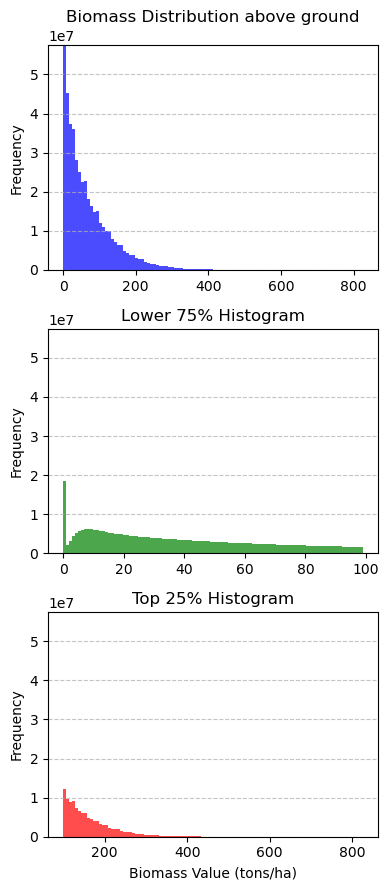

In [242]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRBMO.tif') as src_BMO:
    # Read the data
        data_BMO1 = src_BMO.read(1)  # Reads the first band of the image
        data_BMO2 = src_BMO.read(2)
        data_BMO3 = src_BMO.read(3)

plot_histogram(data_BMO1, bins=100, title='Biomass Distribution above ground',
               xlabel='Biomass Value (tons/ha)', ylabel='Frequency', percentile=75)

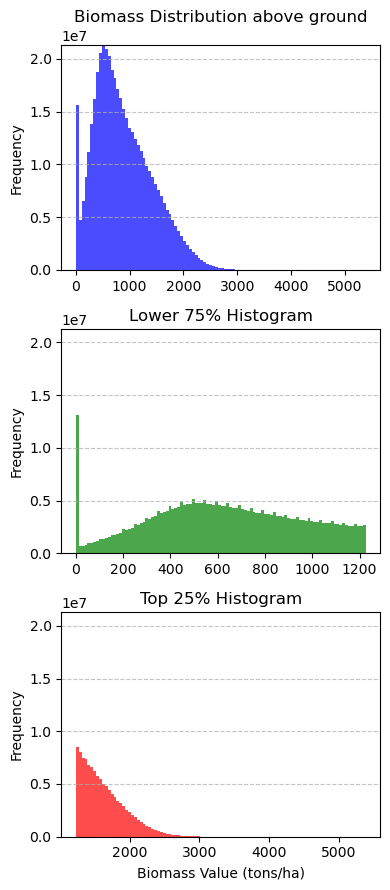

In [314]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREANTALL.tif') as src_TREA:
    # Read the data
        data_TREA1 = src_TREA.read(1)  # Reads the first band of the image
        data_TREA2 = src_TREA.read(2)
        data_TREA3 = src_TREA.read(3)
plot_histogram(data_TREA1, bins=100, title='Treantall per hecter',
               xlabel='trær/ha', ylabel='Frequency', percentile=75)

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRTREALDER.tif') as src_TREALD:
    # Read the data
        data_TREALD1 = src_TREALD.read(1)  # Reads the first band of the image
        data_TREALD2 = src_TREALD.read(2)
        data_TREALD3 = src_TREALD.read(3)

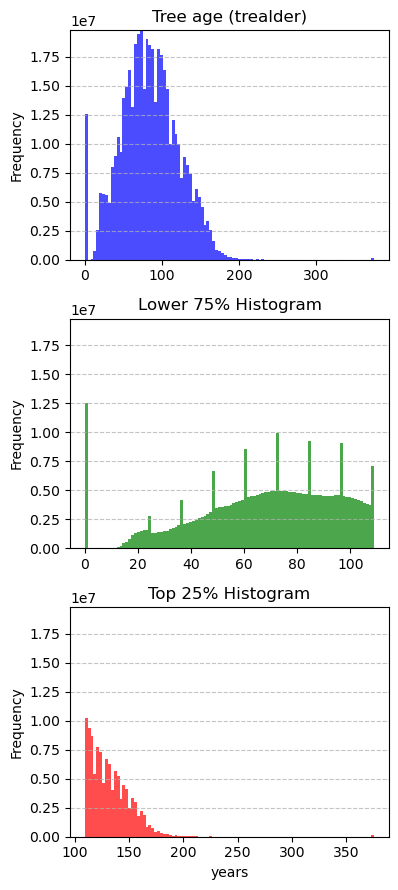

In [343]:
plot_histogram(data_TREALD1, bins=100, title='Tree age (trealder)',
               xlabel='years', ylabel='Frequency', percentile=75)

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRGRFLATE.tif') as src_GRF:
    # Read the data
        data_GRF1 = src_GRF.read(1)  # Reads the first band of the image
        data_GRF2 = src_GRF.read(2)
        data_GRF3 = src_GRF.read(3)

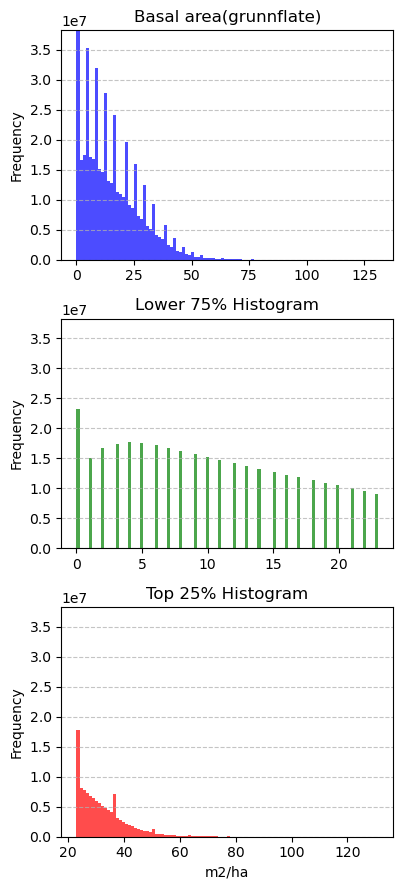

In [345]:
plot_histogram(data_GRF1, bins=100, title='Basal area(grunnflate)',
               xlabel='m2/ha', ylabel='Frequency', percentile=75)

In [ ]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRVOLMB.tif') as src_VOLMB:
    # Read the data
        data_VOLMB1 = src_VOLMB.read(1)  # Reads the first band of the image
        data_VOLMB2 = src_VOLMB.read(2)
        data_VOLMB3 = src_VOLMB.read(3)

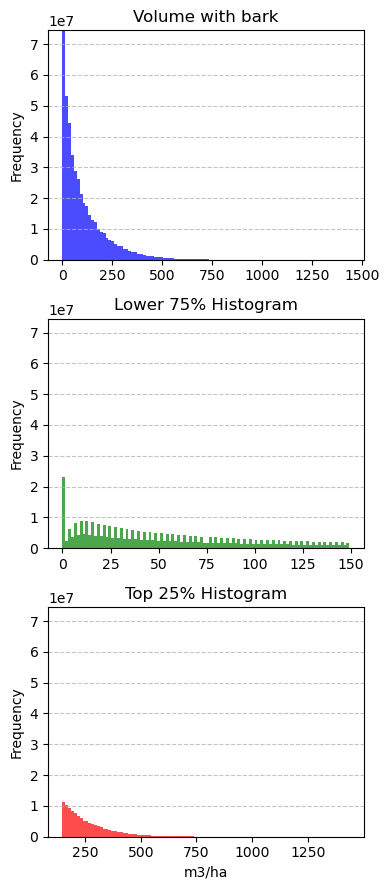

In [347]:
plot_histogram(data_VOLMB1, bins=100, title='Volume with bark',
               xlabel='m3/ha', ylabel='Frequency', percentile=75)

In [3]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRRKRONEDEK.tif') as src_KRO:
    # Read the data
        data_KRO1 = src_KRO.read(1)  # Reads the first band of the image

In [8]:
src_KRO.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -9999.0,
 'width': 78325,
 'height': 96822,
 'count': 1,
 'crs': CRS.from_epsg(25833),
 'transform': Affine(16.0, 0.0, -95616.0,
        0.0, -16.0, 7985152.0)}

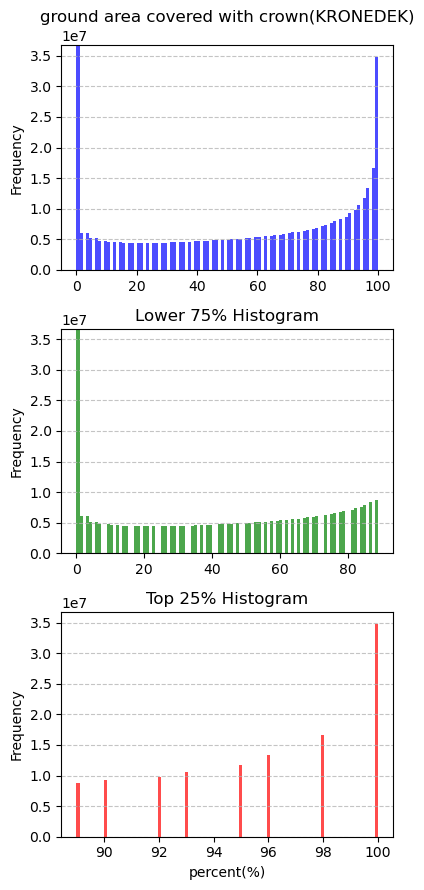

In [6]:
plot_histogram(data_KRO1, bins=100, title='ground area covered with crown(KRONEDEK)',
               xlabel='percent(%)', ylabel='Frequency', percentile=75)

In [173]:
with rasterio.open('/fp/homes01/u01/ec-javedm/ec85/cluster/EFF/0000_25833_SR16_RASTER/SRROHOYDE.tif') as src_ohoy:
    # Read the data
        data_hoy = src_ohoy.read(1)  # Reads the first band of the image


In [174]:
np.unique(data_hoy)

array([-9999,     0,     1,     2,     3,     4,     5,     6,     7,
           8,     9,    10,    11,    12,    13,    14,    15,    16,
          17,    18,    19,    20,    21,    22,    23,    24,    25,
          26,    27,    28,    29,    30,    31,    32,    33,    34,
          35,    36,    37,    38,    39,    40,    41,    42,    43,
          44,    45,    46,    47,    48,    49,    50,    51,    52,
          53,    54,    55,    56,    57,    58,    59,    60,    61,
          62,    63,    64,    65,    66,    67,    68,    69,    70,
          71,    72,    73,    74,    75,    76,    77,    78,    79,
          80,    81,    82,    83,    84,    85,    86,    87,    88,
          89,    90,    91,    92,    93,    94,    95,    96,    97,
          98,    99,   100,   101,   102,   103,   104,   105,   106,
         107,   108,   109,   110,   111,   112,   113,   114,   115,
         116,   117,   118,   119,   120,   121,   122,   123,   124,
         125,   126,

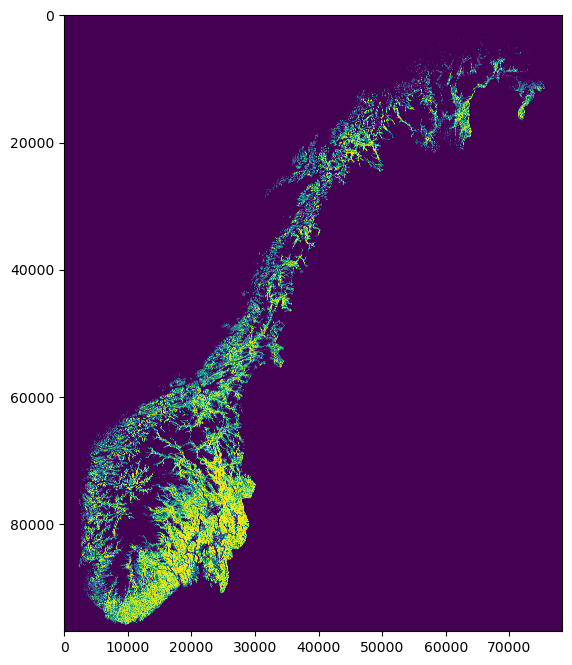

In [14]:
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')

In [ ]:
sharedinputpath = "../../../models/max/special_issue/shared_input/"

In [ ]:
europe = gpd.read_file("resources/data/NO-NUTS3.geojson").replace({"UK":"GB","EL":"GR"}).rename(columns={"NUTS_ID":"index"}).loc[:,["index","geometry"]].sort_values("index").set_index('index')#.loc[desired_regions]

In [ ]:
fig, ax = plt.subplots()

gpd.clip(europe,(0,55,35,74)).plot(
    ax=ax,
    facecolor="none", 
    edgecolor="black",
    alpha = 0.3
)

In [ ]:
categories = ['Fauna','Natur','Neigh','Sami']
scenarios = ['Low','High']

In [ ]:
gpd.read_file('mo/resources/scenario_exclusions/

In [ ]:
#categories = ['Sami','Natur']
#scenarios = ['Low','Med']
row_nr = 0
column_nr = 0
a = 'N/A'

#norway_area = europe.to_crs('EPSG:3857').area.sum()

fig = plt.figure(figsize=(4*3.54,6*3.54), dpi=300,layout="constrained")

gs = fig.add_gridspec(4,2)

for category in categories:
    for scenario in scenarios:
        ax1 = fig.add_subplot(gs[row_nr,column_nr])
        df = gpd.read_file("mo/resources/scenario_exclusions/" + str(category) + "_" + str(scenario) + "_Exc.zip").to_crs('EPSG:4326')
        df.plot(
            ax=ax1,
        )
        
        #a = df.area.sum()/norway_area
        
        gpd.clip(europe,(0,55,35,74)).plot(
            ax=ax1,
            facecolor="none", 
            edgecolor="black",
            alpha = 0.3
        )
        
        ax1.set_title(str(category) + str(scenario) + ' Area: ' + str(a))
        ax1.set_xlim(0,35)
        ax1.set_ylim(55,74)
        
        column_nr += 1
        if column_nr == 2:
            column_nr = 0
            row_nr += 1
   

In [ ]:
pv_low = gpd.read_file("mo/resources/scenario_exclusions/PV_Low_Exc.zip").to_crs('EPSG:4326')

In [ ]:
#axs=plt.subplots(1,3)
fig = plt.figure(figsize=(4*3.54,6*3.54), dpi=300,layout="constrained")

gs = fig.add_gridspec(1,3)

ax1 = fig.add_subplot(gs[0,0])
pv_low.plot(
    ax=ax1
)

#ax2 = fig.add_subplot(gs[0,1])
#pv_med.plot(
#    ax=ax2
#)
#
#ax3 = fig.add_subplot(gs[0,2])
#pv_high.plot(
#    ax=ax3
#)

ax1.set_xlim(0,35)
ax1.set_ylim(55,74)

In [ ]:
pv_med = gpd.read_file("mo/resources/scenario_exclusions/PV_Medium_Exc.zip").to_crs('EPSG:4326')

In [ ]:
pv_high = gpd.read_file("resources/data/PV_High_Exc.zip").to_crs('EPSG:4326')

In [ ]:
technical = gpd.read_file("mo/resources/scenario_exclusions/Techn_All_Exc.zip").to_crs('EPSG:4326')
fauna_low = gpd.read_file("mo/resources/scenario_exclusions/Fauna_Low_Exc.zip").to_crs('EPSG:4326')
#neigh_high = gpd.read_file("mo/resources/scenario_exclusions/Neigh_High_Exc.zip").to_crs('EPSG:4326')
#neigh_med = gpd.read_file("mo/resources/scenario_exclusions/Neigh_Med_Exc.zip").to_crs('EPSG:4326')
natur_high = gpd.read_file("mo/resources/scenario_exclusions/Natur_High_Exc.zip").to_crs('EPSG:4326')

In [ ]:
technical.plot(figsize=(10,6))

## Areas

In [ ]:
neigh_med.to_crs('EPSG:3857').plot()

In [ ]:
neigh_med.to_crs('EPSG:3857').area.sum()

In [ ]:
neigh_med.to_crs('EPSG:3857').area.sum()/europe.to_crs('EPSG:3857').area.sum()

In [ ]:
europe.to_crs('EPSG:3857').area.sum()

In [ ]:
technical.to_crs('EPSG:3857').area.sum()

## Overlay

In [ ]:
df_sami_low = gpd.read_file('resources/data/Sami_Low_Exc.zip').to_crs('EPSG:4326')
df_sami_med = gpd.read_file('resources/data/Sami_Med_Exc.zip').to_crs('EPSG:4326')
df_sami_hig = gpd.read_file('resources/data/Sami_High_Exc.zip').to_crs('EPSG:4326')
extra_area = gpd.read_file('resources/data/0000_25833_reindrift-konsesjonsomrade_shp.zip').to_crs('EPSG:4326')
extra_area_buff = extra_area.copy()
extra_area_buff['geometry'] = extra_area_buff['geometry'].buffer(0.05)

In [ ]:
extra_area.plot()
extra_area_buff.plot()

In [ ]:
df_sami_low['savedindex'] = df_sami_low.index
df_sami_med['savedindex'] = df_sami_med.index
df_sami_hig['savedindex'] = df_sami_hig.index

intersecting_low = extra_area.sjoin(df_sami_low, how='inner')['savedindex']
intersecting_med = extra_area.sjoin(df_sami_med, how='inner')['savedindex']
intersecting_hig = extra_area_buff.sjoin(df_sami_hig, how='inner')['savedindex']

df_sami_low_new = df_sami_low[~df_sami_low.savedindex.isin(intersecting_low)]
df_sami_med_new = df_sami_med[~df_sami_med.savedindex.isin(intersecting_med)]
df_sami_hig_new = df_sami_hig[~df_sami_hig.savedindex.isin(intersecting_hig)]

In [ ]:
row_nr = 0
column_nr = 0

fig = plt.figure(figsize=(4*3.54,6*3.54), dpi=300,layout="constrained")

gs = fig.add_gridspec(3,2)

ax1 = fig.add_subplot(gs[0,0])
df_sami_low.plot(ax=ax1,label='df_sami_low')
ax1.set_title('df_sami_low')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[0,1])
df_sami_low_new.plot(ax=ax1)
ax1.set_title('df_sami_low_new')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[1,0])
df_sami_med.plot(ax=ax1)
ax1.set_title('df_sami_med')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[1,1])
df_sami_med_new.plot(ax=ax1)
ax1.set_title('df_sami_med_new')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[2,0])
df_sami_hig.plot(ax=ax1)
ax1.set_title('df_sami_hig')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

ax1 = fig.add_subplot(gs[2,1])
df_sami_hig_new.plot(ax=ax1)
ax1.set_title('df_sami_hig_new')
ax1.set_xlim(6,33)
ax1.set_ylim(61,72)

plt.savefig('sami_overlays.pdf',bbox_inches='tight')

In [ ]:
sami_list = [df_sami_low_new]

In [ ]:
for item in sami_list:
    item.plot()

In [ ]:
df_sami_low_new.to_file('sami_low_new.geojson',driver='GeoJSON')
df_sami_med_new.to_file('sami_med_new.geojson',driver='GeoJSON')
df_sami_hig_new.to_file('sami_hig_new.geojson',driver='GeoJSON')

In [ ]:
gpd.read_file('sami_hig_new.geojson').plot()